# Задание 4: Энтропия и информационное содержание

Применяем формулы Шеннона и Хартли к матрице PPM

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

## PPM из задания 1

In [2]:
sites = [
    "GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA",
    "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC",
    "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
    "CAGGTTGGC"
]

nucleotides = ['A', 'C', 'G', 'T']
N = len(sites)
L = len(sites[0])
alpha = 0.1

# PFM
pfm = np.zeros((4, L), dtype=int)
nuc_index = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
for seq in sites:
    for pos in range(L):
        pfm[nuc_index[seq[pos]], pos] += 1

# PPM
ppm = [[0] * L for _ in range(4)]
for pos in range(L):
    count_A = pfm[0][pos] + alpha
    count_C = pfm[1][pos] + alpha
    count_G = pfm[2][pos] + alpha
    count_T = pfm[3][pos] + alpha
    total = count_A + count_C + count_G + count_T
    ppm[0][pos] = count_A / total
    ppm[1][pos] = count_C / total
    ppm[2][pos] = count_G / total
    ppm[3][pos] = count_T / total


## 1. Энтропия Шеннона для каждой позиции

$$H(i) = -\sum_{b \in \{A,C,G,T\}} p_{b,i} \log_2 p_{b,i}$$

 $0 \cdot \log_2 0 = 0$.

In [3]:
H = []
for pos in range(L):
    h = 0.0
    for row in range(4):
        p = ppm[row][pos]
        if p > 0:
            h += p * math.log2(p)
    H.append(-h)

print("Энтропия Шеннона H(i):")
for i, h in enumerate(H):
    print(f"  pos{i+1}: H = {h:.4f}")

Энтропия Шеннона H(i):
  pos1: H = 1.6031
  pos2: H = 0.8758
  pos3: H = 1.0309
  pos4: H = 0.2343
  pos5: H = 0.2343
  pos6: H = 1.4480
  pos7: H = 1.0253
  pos8: H = 0.8758
  pos9: H = 1.0309


## 2. Информационное содержание

$$IC(i) = \log_2(4) - H(i) = 2 - H(i)$$

In [4]:
IC = [2 - h for h in H]

print("Информационное содержание IC(i):")
for i, ic in enumerate(IC):
    print(f"  pos{i+1}: IC = {ic:.4f}")

print(f"\nОбщее IC мотива: {sum(IC):.4f} бит")

Информационное содержание IC(i):
  pos1: IC = 0.3969
  pos2: IC = 1.1242
  pos3: IC = 0.9691
  pos4: IC = 1.7657
  pos5: IC = 1.7657
  pos6: IC = 0.5520
  pos7: IC = 0.9747
  pos8: IC = 1.1242
  pos9: IC = 0.9691

Общее IC мотива: 9.6417 бит


## 3. Столбчатая диаграмма IC(i)

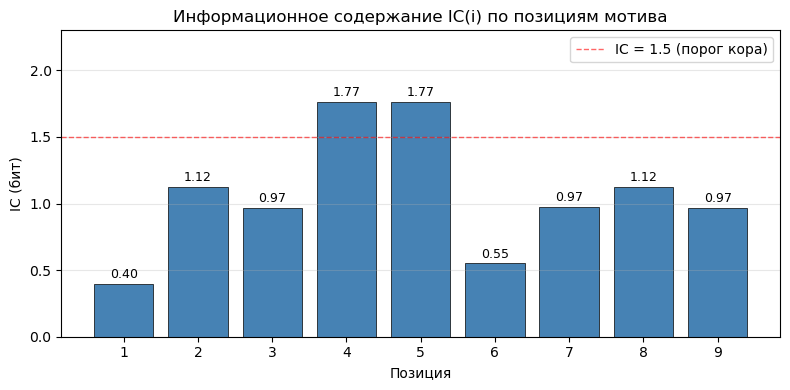

In [5]:
positions = list(range(1, L + 1))

plt.figure(figsize=(8, 4))
bars = plt.bar(positions, IC, color='steelblue', edgecolor='black', linewidth=0.5)

for bar, ic in zip(bars, IC):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{ic:.2f}", ha='center', va='bottom', fontsize=9)

plt.xlabel("Позиция")
plt.ylabel("IC (бит)")
plt.title("Информационное содержание IC(i) по позициям мотива")
plt.xticks(positions)
plt.ylim(0, 2.3)
plt.axhline(y=1.5, color='red', linestyle='--', linewidth=1, alpha=0.6, label="IC = 1.5 (порог кора)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("ic_per_position.png", dpi=150)
plt.show()

## 4. Анализ кор-мотива

In [6]:
print("Исходное выравнивание:")
for s in sites:
    print(" ", s)

print("\nIC по позициям:")
for i, ic in enumerate(IC):
    marker = "  <-- кор" if ic >= 1.5 else ""
    print(f"  pos{i+1}: IC = {ic:.4f}{marker}")

core = [i+1 for i, ic in enumerate(IC) if ic >= 1.5]
var  = [i+1 for i, ic in enumerate(IC) if ic < 1.5]
print(f"\nКор-мотив (IC >= 1.5): позиции {core}")
print(f"Вариабельные позиции:  {var}")
print()
print("Вывод: позиции 2–5 (AGGT) максимально консервативны — это кор мотива.")
print("Визуальный осмотр выравнивания подтверждает: почти все сайты содержат CAGGT.")
print("Позиции 1, 6–9 более вариабельны (низкий IC).")

Исходное выравнивание:
  GAGGTAAAC
  TCCGTAAGC
  CAGGTTGGA
  ACAGTCAGC
  TAGGTCAGC
  CAGGTCAGC
  CAGGTCGAT
  CAGGTCAGC
  CAGGTCAGC
  CAGGTTGGC

IC по позициям:
  pos1: IC = 0.3969
  pos2: IC = 1.1242
  pos3: IC = 0.9691
  pos4: IC = 1.7657  <-- кор
  pos5: IC = 1.7657  <-- кор
  pos6: IC = 0.5520
  pos7: IC = 0.9747
  pos8: IC = 1.1242
  pos9: IC = 0.9691

Кор-мотив (IC >= 1.5): позиции [4, 5]
Вариабельные позиции:  [1, 2, 3, 6, 7, 8, 9]

Вывод: позиции 2–5 (AGGT) максимально консервативны — это кор мотива.
Визуальный осмотр выравнивания подтверждает: почти все сайты содержат CAGGT.
Позиции 1, 6–9 более вариабельны (низкий IC).
